## LSTM Model for Ethereum Forecasting 
## Python Version: 3.9+

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import callbacks # For Early Stopping
import keras_tuner as kt
import plotly.graph_objects as go

## 2. Data Loading and Initial Preparation

In [2]:
# Download Bitcoin data
df_ETH = yf.download(
    tickers=["ETH-USD"],
    start="2020-01-01",
    end="2025-01-01" # yf downloads up to the day before
)

# Basic Cleaning and Selection
df_ETH.columns = ['Open', 'High', 'Low', 'Close', 'Volume'] # Rename for clarity
print(f"Original shape: {df_ETH.shape}")
print('Null Values Before:', df_ETH.isnull().values.sum())
df_ETH.ffill(inplace=True) # Forward fill for potential missing values
print('Null Values After FFill:', df_ETH.isnull().values.sum())

# Select Target and Set Index
df_ETH.reset_index(inplace=True)
df_ETH['Date'] = pd.to_datetime(df_ETH['Date'], format='%Y-%m-%d')
df_ETH = df_ETH[['Date', 'Close']]
df_ETH.set_index('Date', inplace=True)

# Ensure Daily Frequency
df_ETH = df_ETH.asfreq('D')
print('Null Values After AsFreq:', df_ETH.isnull().values.sum())
df_ETH.ffill(inplace=True) # Fill again if necessary
print(f"Shape after preproc: {df_ETH.shape}")
print(f"Frequency of the index: {df_ETH.index.freq}")
print("\nData Head:")
print(df_ETH.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Original shape: (1827, 5)
Null Values Before: 0
Null Values After FFill: 0
Null Values After AsFreq: 0
Shape after preproc: (1827, 1)
Frequency of the index: <Day>

Data Head:
                 Close
Date                  
2020-01-01  129.630661
2020-01-02  130.820038
2020-01-03  127.411263
2020-01-04  134.168518
2020-01-05  135.072098


## 3. Data Visualization

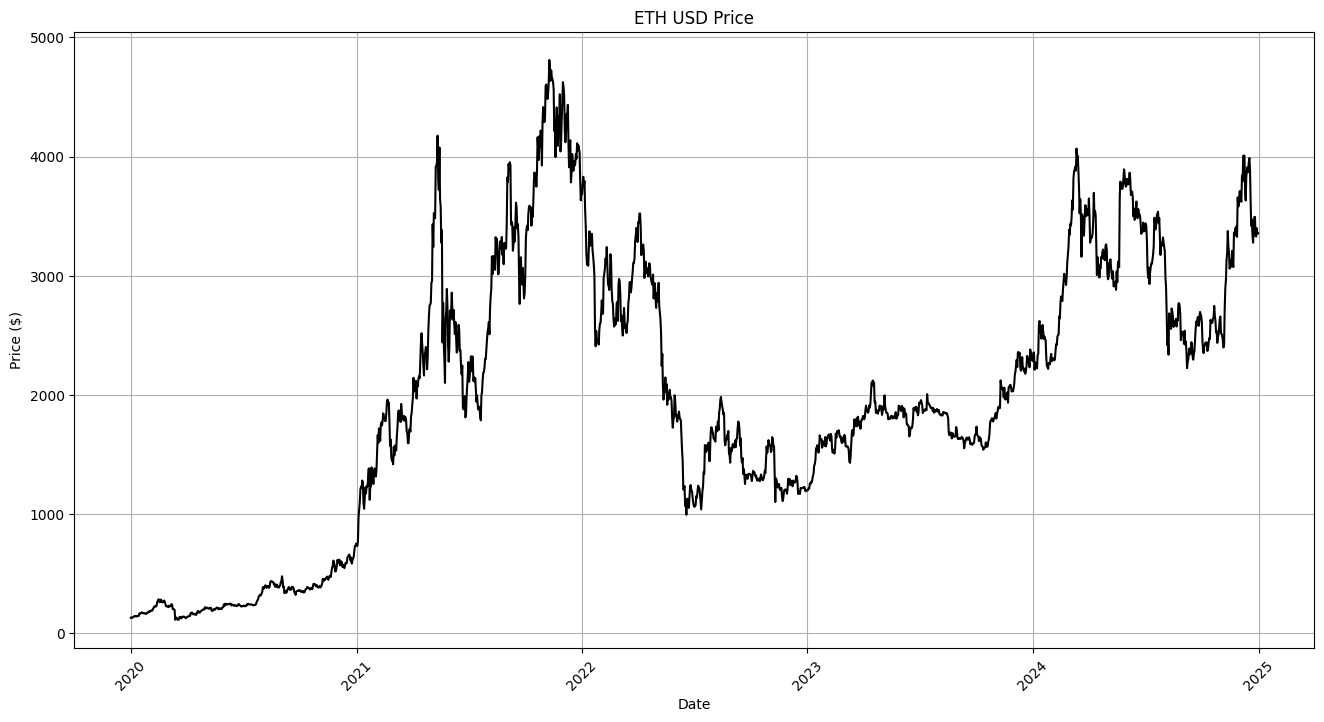

In [3]:
# Plot the close price
plt.figure(figsize=(16,8))
plt.plot(df_ETH.index, df_ETH['Close'], color='black') # Use index for x-axis
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')
plt.title('ETH USD Price')
plt.grid(True)
plt.show()

## 4. Data Splitting and Scaling

In [4]:
# Extract the 'Close' column values
close_prices = df_ETH['Close']
values = close_prices.values.reshape(-1, 1) # Reshape to 2D array for scaler

# Define split sizes (e.g., 60% train, 20% validation, 20% test)
n_total = len(values)
training_data_len = int(n_total * 0.60)
validation_data_len = int(n_total * 0.20)
test_data_len = n_total - training_data_len - validation_data_len

print(f"Total samples: {n_total}")
print(f"Training samples: {training_data_len}")
print(f"Validation samples: {validation_data_len}")
print(f"Test samples: {test_data_len}")

# --- CORRECTED SCALING ---
# 1. Separate training data portion for fitting the scaler
train_values_for_scaler = values[0:training_data_len]

# 2. Fit the scaler ONLY on the training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_values_for_scaler)
print("\nScaler fitted on training data only.")

# 3. Transform the ENTIRE dataset using the FITTED scaler
scaled_data = scaler.transform(values)
# --- END CORRECTION ---

# Define indices for splitting the SCALED data
train_idx_end = training_data_len
val_idx_end = training_data_len + validation_data_len

# Create slices from scaled data (These are the targets for each set)
train_data_scaled = scaled_data[0:train_idx_end, :]
val_data_scaled = scaled_data[train_idx_end:val_idx_end, :]
test_data_scaled = scaled_data[val_idx_end:, :] # This is technically not needed for targets

# Prepare data slices *for sequence generation*, including overlap for lookback
look_back = 60 # Define lookback period (number of time steps)

# Train sequences: Use only train_data_scaled
# Validation sequences: Need data from end of train up to end of validation
val_data_for_seq = scaled_data[train_idx_end - look_back : val_idx_end, :]
# Test sequences: Need data from end of validation up to end of test
test_data_for_seq = scaled_data[val_idx_end - look_back :, :]

Total samples: 1827
Training samples: 1096
Validation samples: 365
Test samples: 366

Scaler fitted on training data only.


## 5. Sequence Generation for LSTM

In [5]:
# Function to create sequences
def create_sequences(data, look_back):
    X, Y = [], []
    for i in range(look_back, len(data)):
        X.append(data[i - look_back:i, 0])
        Y.append(data[i, 0])
    return np.array(X), np.array(Y)

# Create training sequences
x_train, y_train = create_sequences(train_data_scaled, look_back)

# Create validation sequences
# Important: Target y_val should only be from the actual validation period
x_val, y_val_full_seq = create_sequences(val_data_for_seq, look_back)
# y_val needs to align with x_val, representing the actual validation targets
y_val = y_val_full_seq # The function already aligns Y with the end of the X sequence window

# Create test sequences (only need X)
x_test, _ = create_sequences(test_data_for_seq, look_back) # We don't need Y from scaled test data


# Reshape inputs for LSTM [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_val = np.reshape(x_val, (x_val.shape[0], x_val.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Get the *original, unscaled* test values for final evaluation
y_test_unscaled = values[val_idx_end:] # Targets for the test period

# Verify shapes
print("\n--- Sequence Shapes ---")
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape) # Should match x_val's first dimension
print('x_test shape:', x_test.shape)
print('y_test_unscaled shape:', y_test_unscaled.shape) # Should match x_test's first dimension


--- Sequence Shapes ---
x_train shape: (1036, 60, 1)
y_train shape: (1036,)
x_val shape: (365, 60, 1)
y_val shape: (365,)
x_test shape: (366, 60, 1)
y_test_unscaled shape: (366, 1)


## 6. Hyperparameter Tuning with Keras Tuner

In [6]:
# Define the model building function for Keras Tuner
def build_model(hp):
    model = Sequential()
    model.add(LSTM(units=hp.Int('units_1', min_value=32, max_value=128, step=32), # Tune units
                   return_sequences=True,
                   input_shape=(look_back, 1))) # Use look_back variable
    # Optional: Add Dropout
    # model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(LSTM(units=hp.Int('units_2', min_value=32, max_value=128, step=32), # Tune units
                   return_sequences=False))
    # Optional: Add Dropout
    # model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(units=hp.Int('dense_units', min_value=16, max_value=64, step=16))) # Tune units
    model.add(Dense(1)) # Output layer

    # Tune learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error') # MSE for regression
    return model

# Initialize the tuner (RandomSearch is often efficient)
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',       # Minimize validation loss
    max_trials=10,              # Number of different hyperparameter combinations to try
    executions_per_trial=2,     # Train each combination twice for robustness
    directory='keras_tuner_dir', # Directory to store results
    project_name='ETH_lstm_tuning_corrected' # Name for this tuning project
)

# Define early stopping for the tuning search itself to save time
tuner_early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Perform hyperparameter search
print("\n--- Starting Hyperparameter Search ---")
tuner.search(x_train, y_train,
             epochs=50,        # Max epochs per trial during search (can be higher)
             validation_data=(x_val, y_val),
             callbacks=[tuner_early_stopping],
             verbose=1)       # Show progress

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
--- Hyperparameter Search Complete ---
Best Hyperparameters Found:
- LSTM Layer 1 Units: {best_hps.get('units_1')}
- LSTM Layer 2 Units: {best_hps.get('units_2')}
- Dense Layer Units: {best_hps.get('dense_units')}
- Learning Rate: {best_hps.get('learning_rate')}
""")
# - Dropout 1: {best_hps.get('dropout_1')} # Uncomment if dropout is added
# - Dropout 2: {best_hps.get('dropout_2')} # Uncomment if dropout is added


Trial 10 Complete [00h 00m 55s]
val_loss: 0.0001361042886856012

Best val_loss So Far: 0.00013373733600019477
Total elapsed time: 00h 19m 51s

--- Hyperparameter Search Complete ---
Best Hyperparameters Found:
- LSTM Layer 1 Units: 128
- LSTM Layer 2 Units: 32
- Dense Layer Units: 64
- Learning Rate: 0.01



## 7. Train Final Model with Best Hyperparameters 

In [7]:
# Build the final model using the best hyperparameters found
final_model = build_model(best_hps) # Or tuner.hypermodel.build(best_hps)

# Define an early stopping callback for final training
final_early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the final model on the full training data, validate on validation data
print("\n--- Training Final LSTM Model ---")
history_final = final_model.fit(
    x_train, y_train,
    epochs=100,             # Train for potentially more epochs, early stopping will handle duration
    # Determine batch size from tuning results if available, else use a default
    batch_size=best_hps.get('batch_size') if 'batch_size' in best_hps else 32, # Tuner doesn't tune batch_size by default in this setup
    validation_data=(x_val, y_val),
    callbacks=[final_early_stopping],
    verbose=1
)

print("\n--- Final Model Training Complete ---")
final_model.summary()


--- Training Final LSTM Model ---
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - loss: 0.1417 - val_loss: 3.4979e-04
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - loss: 0.0017 - val_loss: 2.9113e-04
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - loss: 0.0015 - val_loss: 6.5304e-04
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0014 - val_loss: 3.4764e-04
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 125ms/step - loss: 0.0010 - val_loss: 6.0371e-04
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 0.0014 - val_loss: 1.5363e-04
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 8.8626e-04 - val_loss: 2.5685e-04
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - loss: 9.2912e-04 - val_loss: 2.5511e-04
Epoch 9/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0011 - val_loss: 6.7912e-04
Epoch 10/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - loss: 0.0013 - val_loss: 1.5616e-04
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 108

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,037 (1.02 MB)

 Trainable params: 89,345 (349.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 178,692 (698.02 KB)

## 8. Make Predictions on Test Set

In [8]:
print("\n--- Making Predictions on Test Set ---")
# Use the FINAL trained model
predictions_scaled = final_model.predict(x_test)

# Inverse transform the predictions to get actual price values
# Use the scaler that was fitted ONLY on the training data
predictions_unscaled = scaler.inverse_transform(predictions_scaled)


--- Making Predictions on Test Set ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


## 9. Evaluate Model Performance

In [9]:
# Calculate evaluation metrics using unscaled predictions and unscaled actuals
rmse_lstm = np.sqrt(mean_squared_error(y_test_unscaled, predictions_unscaled))
mae_lstm = mean_absolute_error(y_test_unscaled, predictions_unscaled)
mape_lstm = mean_absolute_percentage_error(y_test_unscaled, predictions_unscaled)
try:
    r2_lstm = r2_score(y_test_unscaled, predictions_unscaled)
except ValueError: # Handle potential edge cases for R2
    r2_lstm = np.nan

# Print Evaluation Metrics
print("\n--- LSTM Model Evaluation Metrics (Hold-out Set) ---")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape_lstm:.4%}")
print(f"R-squared (R²): {r2_lstm:.4f}")

# Print Metrics for Comparison Table in Thesis
print("\n--- LSTM Hold-out Metrics (for Thesis Table) ---")
print(f"LSTM Hold-out RMSE:  {rmse_lstm:.4f}")
print(f"LSTM Hold-out MAE:   {mae_lstm:.4f}")
print(f"LSTM Hold-out MAPE:  {mape_lstm:.4%}")
print(f"LSTM Hold-out R²:    {r2_lstm:.4f}")


--- LSTM Model Evaluation Metrics (Hold-out Set) ---
Root Mean Squared Error (RMSE): 141.6270
Mean Absolute Error (MAE): 105.1513
Mean Absolute Percentage Error (MAPE): 3.4717%
R-squared (R²): 0.9230

--- LSTM Hold-out Metrics (for Thesis Table) ---
LSTM Hold-out RMSE:  141.6270
LSTM Hold-out MAE:   105.1513
LSTM Hold-out MAPE:  3.4717%
LSTM Hold-out R²:    0.9230


## 10. Prepare Data for Plotting and Visualize Results

In [10]:
# Get original data indices corresponding to train/val/test periods
train_dates = df_ETH.index[:training_data_len]
val_dates = df_ETH.index[training_data_len:val_idx_end]
test_dates = df_ETH.index[val_idx_end:]

# Ensure prediction length matches test dates length
if len(predictions_unscaled) != len(test_dates):
    print(f"Warning: Length mismatch between predictions ({len(predictions_unscaled)}) and test dates ({len(test_dates)}). Adjusting plot data.")
    # Attempt to align - this assumes prediction starts on the first test date
    min_len = min(len(predictions_unscaled), len(test_dates))
    plot_test_dates = test_dates[:min_len]
    plot_predictions = predictions_unscaled[:min_len]
    plot_y_test_unscaled = y_test_unscaled[:min_len]
else:
    plot_test_dates = test_dates
    plot_predictions = predictions_unscaled
    plot_y_test_unscaled = y_test_unscaled


# Create DataFrames for plotting
train_plot_df = pd.DataFrame({'Date': train_dates, 'Close': df_ETH['Close'][:training_data_len]})
val_plot_df = pd.DataFrame({'Date': val_dates, 'Close': df_ETH['Close'][training_data_len:val_idx_end]})
test_plot_df = pd.DataFrame({'Date': plot_test_dates, 'Close': plot_y_test_unscaled.flatten(), 'Predictions': plot_predictions.flatten()})


# Plot the results using Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=train_plot_df.Date, y=train_plot_df.Close, mode='lines', name='Actual Price (Train)', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=val_plot_df.Date, y=val_plot_df.Close, mode='lines', name='Actual Price (Validation)', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=test_plot_df.Date, y=test_plot_df.Close, mode='lines', name='Actual Price (Test)', line=dict(color='green')))
fig.add_trace(go.Scatter(x=test_plot_df.Date, y=test_plot_df.Predictions, mode='lines', name='LSTM Predicted price', line=dict(color='red', dash='dash')))

fig.update_layout(
    title="Bitcoin Price Forecasting using LSTM (Corrected)",
    xaxis_title="Date",
    yaxis_title="Price (USD)",
    legend_title="Legend",
    template="plotly_white"
)
fig.show()

## 11. Data Split Summary

In [11]:
# Show counts and date ranges for training, validation, and test sets
# Use the original data indices for clarity
train_start_date = df_ETH.index[0]
train_end_date = df_ETH.index[training_data_len - 1]
train_count = training_data_len

# Validation set dates (actual period)
val_start_date = df_ETH.index[training_data_len]
val_end_date = df_ETH.index[val_idx_end - 1]
val_count = validation_data_len

# Test set dates
test_start_date = df_ETH.index[val_idx_end]
test_end_date = df_ETH.index[-1]
test_count = test_data_len

print("\n--- Data Split Summary ---")
print(f"Training Set:   {train_count} data points from {train_start_date.strftime('%Y-%m-%d')} to {train_end_date.strftime('%Y-%m-%d')}")
print(f"Validation Set: {val_count} data points from {val_start_date.strftime('%Y-%m-%d')} to {val_end_date.strftime('%Y-%m-%d')}")
print(f"Test Set:       {test_count} data points from {test_start_date.strftime('%Y-%m-%d')} to {test_end_date.strftime('%Y-%m-%d')}")


--- Data Split Summary ---
Training Set:   1096 data points from 2020-01-01 to 2022-12-31
Validation Set: 365 data points from 2023-01-01 to 2023-12-31
Test Set:       366 data points from 2024-01-01 to 2024-12-31
